# Basic Concepts of Deep Learning
## A summer school for environmental scientists

AI-readiness is one of the important aspects of the next funding phase of the Helmholtz centers. This not only means the integration of existing AI tools into workflows, and goes beyond the inclusion of foundational models in scientific research. AI and Deep Learning in particular have seen growth for years now, but the knowledge level about Deep Learning is very diverse across domains and even specific topics.

Some topics, such as remote sensisng, have used DL-based techniques successfully for years, while other specific domains still struggle with finding pathways of integrating DL in their workflows. This workshop is an attempt to produce teaching material which will allow researchers from a diverse background to utilize and integrate AI in their workflows. Note that this is not a course on language models (LLMs), but rather a course which teaches:

- Fundamentals of Machine and Deep Learning
- Basics of PyTorch, a scalable DL library
- Training a Neural Network
- Supervised vs Unsupervised learning
- Examples and Exercises

We hope researchers at the Helmholtz Center for Environmental Research will benefit from the course and its contents. Since this is a concept course, we strongly depend on your feedback and participation. If you signed up but feel like you cannot fit the course into your schedule, please change your registration.

## Prerequisites

This is not a Python introduction course. Participants are expected to be familiar with Python basics, including scripting, functions, conditional statements and loops, and ideally some data analytics library such as Pandas or Numpy.

The course will teach basics of Deep Learning without requiring understanding of mathematical statistics.

## More fine-granular concept

0. Users setup their environment according to best practices
   1. PyTorch installation via website
   2. Users with existing cluster access may use the compute cluster
   3. In both cases, we setup a Python virtual environment
   4. For users preferring conda, we provide a yml file

1. Introduction to Deep Learning
   1. Basics of learning theory
   2. Estimation and Regression
   3. Discriminative Learning

2. Exercise <-- THIS DOCUMENT
   1. Setup a PyTorch Tensor
   2. Calculating with Tensors
   3. Loss functions
   4. Perceptron learning

In [1]:
from IPython.display import *
import re

def prefilter(*text, sep=" ", **kwargs):
  content = sep.join(map(str, text))
  # if you find `` enclosing some text with no whitespace between ` and the text, then we will assume that it is a code snippet and we will not apply markdown formatting to it
  # search for pairs of `` with some a-zA-Z0-9_ characters in between, and replace them with <code>...</code>
  content = re.sub(r"``([a-zA-Z0-9_]+)``", r"<code>\1</code>", content)
  return content

def header(*text, level=2, sep=" ", **kwargs):
  content = sep.join(map(str, text))
  display(HTML(f"<h{level}>{content}</h{level}>"))

def paragraph(text):
  content = prefilter(text)
  display(Markdown(content))

def boldface(*text, sep=" ", **kwargs):
  content = sep.join(map(str, text))
  display(HTML(f"<b>{content}</b>"))

def italic(*text, sep=" ", **kwargs):
  content = sep.join(map(str, text))
  display(HTML(f"<i>{content}</i>"))

def hidden(*text, summary=None, **kwargs):
  content = prefilter(*text, **kwargs)
  if summary is not None:
    display(HTML(f"<details><summary>{summary}</summary><p>{content}</p></details>"))
  else:
    display(HTML(f"<details><summary>Click here</summary><p>{content}</p></details>"))


In [2]:
# for animated plots, import HTML element-tree support
import gc
import io
import os
import sys
import re
import textwrap
import matplotlib.pyplot as plt

# mandatory householding: reset animation folder and delete its contents
for file in os.listdir(".animation_frames/") :
  os.remove(".animation_frames/" + file)

class animated_plot:
  def __init__(self, fig, create_fig=None, cache_dir=".animation_frames"):
    import uuid
    self.fig = fig
    self.svgs = []
    self.svg_files = []
    self.create_fig = create_fig
    self.cache_dir = cache_dir
    self.cache_prefix = f"anim_{uuid.uuid4().hex}"
    os.makedirs(self.cache_dir, exist_ok=True)

  def _close_current_fig(self):
    if self.fig is not None:
      old_fig = self.fig
      self.fig = None
      plt.close(old_fig)
      del old_fig
      gc.collect()

  def step(self):
    # draw the canvas then export the figure to an SVG buffer
    self.fig.canvas.draw()
    buf = io.BytesIO()
    self.fig.savefig(buf, format="svg", bbox_inches="tight")
    svg = buf.getvalue().decode("utf-8")
    buf.close()
    # strip XML prolog/DOCTYPE/comments which can break embedding in HTML
    svg = re.sub(r'^\s*<\?xml[^>]*\?>\s*', '', svg, flags=re.I | re.S)
    svg = re.sub(r'^\s*<!DOCTYPE[^>]*>\s*', '', svg, flags=re.I | re.S)
    svg = re.sub(r'^\s*<!--.*?-->\s*', '', svg, flags=re.S)
    svg = svg.lstrip()
    self.svgs.append(svg)

    # cache each frame as an SVG file and keep relative paths for HTML output
    frame_index = len(self.svgs) - 1
    frame_name = f"{self.cache_prefix}_{frame_index:04d}.svg"
    frame_path = os.path.join(self.cache_dir, frame_name)
    with open(frame_path, "w", encoding="utf-8") as f:
      f.write(svg)
    self.svg_files.append(frame_path.replace(os.sep, "/"))

    # close figure to release resources (prevents many-open-figures warning)
    self._close_current_fig()

  def set_fig(self, fig):
    self.fig = fig

  def reinit_fig(self):
    # If a create_fig callable is provided, call it to re-create the figure
    # and axes, update internal fig reference, and return (fig, axes).
    # Returns (self.fig, None) if no create_fig is available.
    if self.create_fig is None:
      return self.fig, None

    # explicitly delete previous figure before creating a new one
    self._close_current_fig()

    new = self.create_fig()
    # create_fig expected to return (fig, (ax1, ax2)) or similar
    if isinstance(new, tuple) and len(new) >= 1:
      self.fig = new[0]
      if len(new) > 1:
        return self.fig, new[1]
      return self.fig, None
    # fallback: set fig directly
    self.fig = new
    return self.fig, None

  def render(self, playback_speed=0.5):
    import uuid
    slider_id = f"anim_slider_{uuid.uuid4().hex}"
    image_id = f"anim_image_{uuid.uuid4().hex}"
    play_id = f"anim_play_{uuid.uuid4().hex}"
    repeat_id = f"anim_repeat_{uuid.uuid4().hex}"

    parts = []
    parts.append('<div style="width: 100%; max-width: 1100px;">')

    use_files = len(self.svg_files) == len(self.svgs) and len(self.svg_files) > 0
    if use_files:
      first_src = f"{self.svg_files[0]}?v=0"
      parts.append(f'<img id="{image_id}" src="{first_src}" style="width:100%; height:auto; display:block;"/>')
      max_idx = max(0, len(self.svgs) - 1)
      parts.append(f'<input id="{slider_id}" type="range" min="0" max="{max_idx}" value="0" style="margin-top: 10px; width:100%;"/>')
      parts.append(f'<div style="margin-top:6px; display:flex; gap:8px;">')
      parts.append(f'<button id="{play_id}">Play</button>')
      parts.append(f'<button id="{repeat_id}">Repeat: OFF</button>')
      parts.append('</div>')

      playback_ms = max(1, int(playback_speed * 1000))
      file_array = ', '.join([f'"{p}?v={i}"' for i, p in enumerate(self.svg_files)])
      js = f"""<script>
  (function(){{
    var slider = document.getElementById("{slider_id}");
    var img = document.getElementById("{image_id}");
    var playBtn = document.getElementById("{play_id}");
    var repeatBtn = document.getElementById("{repeat_id}");
    var frames = [{file_array}];
    if (!slider || !img || frames.length === 0) return;
    var playbackInterval = {playback_ms};
    var timer = null;
    var repeat = false;

    function updateImage(idx){{
      idx = Math.max(0, Math.min(frames.length - 1, idx || 0));
      img.src = frames[idx];
      slider.value = idx;
    }}

    function advance(){{
      var idx = Number(slider.value) || 0;
      if (idx >= frames.length - 1) {{
        if (repeat) {{
          idx = 0;
        }} else {{
          stop();
          return;
        }}
      }} else {{
        idx = idx + 1;
      }}
      updateImage(idx);
    }}

    function start(){{
      if (timer) return;
      timer = setInterval(advance, playbackInterval);
      playBtn.textContent = "Pause";
    }}
    function stop(){{
      if (!timer) return;
      clearInterval(timer);
      timer = null;
      playBtn.textContent = "Play";
    }}
    function togglePlay(){{
      if (timer) stop(); else start();
    }}

    playBtn.addEventListener('click', togglePlay);
    repeatBtn.addEventListener('click', function(){{
      repeat = !repeat;
      repeatBtn.textContent = "Repeat: " + (repeat ? "ON" : "OFF");
    }});

    slider.addEventListener('input', function(e){{
      updateImage(Number(e.target.value));
    }});
    // initialize
    updateImage(0);
  }})();
  </script>"""
      js = textwrap.dedent(js).strip()
      parts.append(js)
    else:
      if len(self.svgs) > 0:
          parts.append(self.svgs[0])
      else:
          parts.append('<p>No animation frames recorded yet.</p>')
    parts.append('</div>')
    html = ''.join(parts)
    html_object = HTML(html)
    display(html_object)

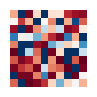

In [3]:
# helper colormap based on RdBu but BuRd
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from matplotlib import pyplot as plt

RdBu_r = plt.get_cmap("RdBu_r")
BuRd_r = LinearSegmentedColormap.from_list("BuRd_r", RdBu_r(np.linspace(0, 1, RdBu_r.N))[::-1])

# extremely small test
fig, ax = plt.subplots(figsize=(1,1))
im = ax.imshow(np.random.gamma(0.5, size=(10,10)), cmap=BuRd_r, vmin=0, vmax=1)
ax.set_axis_off()
plt.show()

# First Section: Loading Torch and Verifying it works

In [4]:
# libraries we need
import numpy as np
from matplotlib import pyplot as plt
# let us load pytorch
import torch
print(f"PyTorch version: {torch.__version__}")
print("Welcome to the 2026 Deep Learning Summer School!")

PyTorch version: 2.10.0+cpu
Welcome to the 2026 Deep Learning Summer School!


In [5]:
header("Let us start working with tensors!", level=3)
tensor_example_data = [[1, 2], [3, 4]]
tensor_example = torch.tensor(tensor_example_data)
print(tensor_example)
paragraph("This is a 2D tensor, which you can just interpret as a matrix for the time being. What is so interesting about the torch library is that it provides a lot of useful functions for tensors, including, for example, the ability to \"trace\" operations on tensors, allowing the library to compute gradients for each operation automatically:")

# keep `gradient_example` as a leaf tensor, perform operations on `result`
gradient_example = torch.tensor(1.0, requires_grad=True)
result = gradient_example * 2
result = result ** 2
result.backward()
print(f"Original tensor: {gradient_example}")
print(f"Result of operations: {result}")
print(f"Gradient of the original tensor: {gradient_example.grad}")

paragraph("Explanation: we start with a tensor `gradient_example` that has `requires_grad=True`, which means that PyTorch will keep track of all operations performed on this tensor. We then perform some operations on it, and finally call `backward()` on the result, which computes the gradient of the original tensor with respect to the result. In this case, the gradient is 8, which is the derivative of `result` with respect to `gradient_example` at the value of 1.0.")

tensor([[1, 2],
        [3, 4]])


This is a 2D tensor, which you can just interpret as a matrix for the time being. What is so interesting about the torch library is that it provides a lot of useful functions for tensors, including, for example, the ability to "trace" operations on tensors, allowing the library to compute gradients for each operation automatically:

Original tensor: 1.0
Result of operations: 4.0
Gradient of the original tensor: 8.0


Explanation: we start with a tensor `gradient_example` that has `requires_grad=True`, which means that PyTorch will keep track of all operations performed on this tensor. We then perform some operations on it, and finally call `backward()` on the result, which computes the gradient of the original tensor with respect to the result. In this case, the gradient is 8, which is the derivative of `result` with respect to `gradient_example` at the value of 1.0.

In [6]:
header("Working with tensors: What is a tensor, exactly?", level=3)
paragraph("An introductory note on the name: in mathematics, a tensor is a map which takes a number of vectors and a number of covectors (linear operations) and produces a number. Usually we use tensors in computer science as meaning 'multidimensional array', and this is not exactly wrong, but we have to note that we are using the word tensor in this course somewhat loosely. In PyTorch, a tensor is a multidimensional array that can be used for various operations, including mathematical computations and machine learning tasks. Tensors can have different dimensions, such as scalars (0D), vectors (1D), matrices (2D), and higher-dimensional arrays (3D and above). They are the fundamental data structure in PyTorch and are used to represent data and parameters in neural networks.")

header("Creating tensors", level=3)
paragraph("There are many ways to create tensors in PyTorch. Here are some examples:")

# Create a tensor from a list
tensor_from_list = torch.tensor([[1, 2], [3, 4]])
print("Tensor from list:")
print(tensor_from_list)

# Create a tensor of zeros
tensor_zeros = torch.zeros((2, 3))
print("\nTensor of zeros:")
print(tensor_zeros)

# Create a tensor from a numpy array
example_numpy_array = np.array([[5, 6], [7, 8]])
tensor_from_numpy = torch.from_numpy(example_numpy_array)
print("\nTensor from numpy array:")
print(tensor_from_numpy)

boldface("Note that the numpy array has a type: ")
print(f"Type of numpy array: {example_numpy_array.dtype}")
paragraph("When we create a tensor from a numpy array, the tensor will have the same data type as the numpy array. In this case, the tensor will have the data type `torch.int64` because the numpy array has the data type `int64`. You can check the data type of a tensor using the `dtype` attribute:")
print(f"Data type of tensor from numpy: {tensor_from_numpy.dtype}")

boldface("Tensors adapt to data type requirements just as Python does:")
tensor_a = torch.tensor([1, 2, 3], dtype=torch.int32)
tensor_b = torch.tensor([4, 5, 6], dtype=torch.int32)
result_division = tensor_a / tensor_b
print("\nResult of division:")
print(result_division)
print(f"Data type of result: {result_division.dtype}")
paragraph("In this case, the result of the division is a floating-point tensor with data type `torch.float32`, even though the original tensors were of type `torch.int32`. This is because PyTorch promotes the data type to a more general type to avoid loss of information during the division operation.")

hidden("Loss of information is a little bit of a misnomer, as `float`, even `float64`, which is a highly resolved floating point number, does not represent all numbers that you could think of. Floats are good approximations of numbers, such as 0.1, but certain numbers cannot be represented exactly, and you might find certain integers that do not have a direct float equivalent, leading to a failure of the direct arithmetic comparison.", summary="Loss of information in data types")

An introductory note on the name: in mathematics, a tensor is a map which takes a number of vectors and a number of covectors (linear operations) and produces a number. Usually we use tensors in computer science as meaning 'multidimensional array', and this is not exactly wrong, but we have to note that we are using the word tensor in this course somewhat loosely. In PyTorch, a tensor is a multidimensional array that can be used for various operations, including mathematical computations and machine learning tasks. Tensors can have different dimensions, such as scalars (0D), vectors (1D), matrices (2D), and higher-dimensional arrays (3D and above). They are the fundamental data structure in PyTorch and are used to represent data and parameters in neural networks.

There are many ways to create tensors in PyTorch. Here are some examples:

Tensor from list:
tensor([[1, 2],
        [3, 4]])

Tensor of zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

Tensor from numpy array:
tensor([[5, 6],
        [7, 8]])


Type of numpy array: int64


When we create a tensor from a numpy array, the tensor will have the same data type as the numpy array. In this case, the tensor will have the data type `torch.int64` because the numpy array has the data type `int64`. You can check the data type of a tensor using the `dtype` attribute:

Data type of tensor from numpy: torch.int64



Result of division:
tensor([0.2500, 0.4000, 0.5000])
Data type of result: torch.float32


In this case, the result of the division is a floating-point tensor with data type `torch.float32`, even though the original tensors were of type `torch.int32`. This is because PyTorch promotes the data type to a more general type to avoid loss of information during the division operation.

## What is a gradient?

Let us consider the simple example of a function which has a somewhat diverse field. What we are searching for is the minimum of the function, thus `find` $x$ such that $x := argmin f(x) \forall x \in \mathbb{R}^3$.

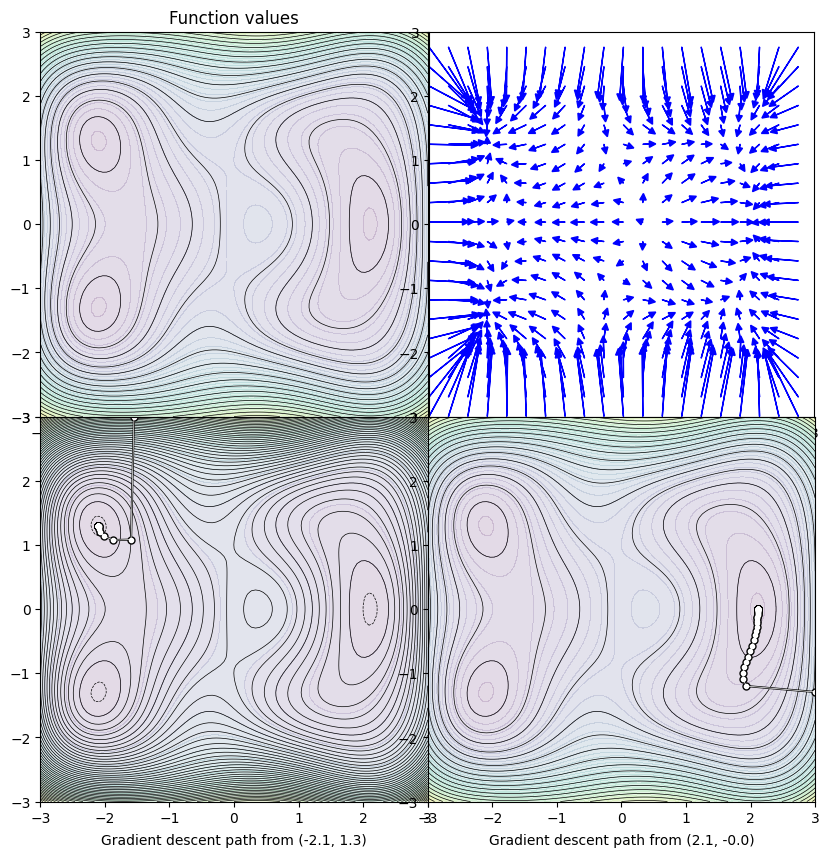

In [ ]:
header("Some basic visualizations of gradients", level=3)
# pick two starting points and compute gradient-descent paths using NumPy
# define a NumPy version of the example function and a numeric gradient (central differences)
def f_example(pt):
  # support both a single 1D point (shape (2,)) and an array of points (...,2)
  x = pt[..., 0]
  y = pt[..., 1]
  return (x**2 - 4)**2 + (y**2 - 1)**2 + np.sin(x * 2.0) * np.cos(y * 2.0) * 4.0

# create 1D axis and 2D grid
x_lin = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_lin, x_lin)             # both shape (100,100)

# build input points for torch
xy = np.stack([X.ravel(), Y.ravel()], axis=-1)
# evaluate function and reshape to grid
Z = f_example(xy).reshape(X.shape)

# make a subplot with no spaces, 2x2
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
fig.subplots_adjust(hspace=0.0, wspace=0.0)
# set the limits to be the same for all subplots
for ax in axs.flat:
  ax.set_xlim(-3, 3)
  ax.set_ylim(-3, 3)
# disable autoscaling
plt.autoscale(False)
topleft = axs[0, 0]
topright = axs[0, 1]
bottomleft = axs[1, 0]
bottomright = axs[1, 1]
# correct contour call using 2D grids
# use a faint filled colormap (low alpha) and strong contour outlines
cf = topleft.contourf(X, Y, Z, levels=50, cmap="viridis", alpha=0.15)
# add black contour lines (outlines) on top for clarity
cs = topleft.contour(X, Y, Z, levels=20, colors="k", linewidths=0.5)
# for later reference, also plot the contour bottomleft and right
bottomleft.contourf(X, Y, Z, levels=20, cmap="viridis", alpha=0.15)
bottomleft.contour(X, Y, Z, levels=50, colors="k", linewidths=0.5)
bottomright.contourf(X, Y, Z, levels=50, cmap="viridis", alpha=0.15)
bottomright.contour(X, Y, Z, levels=20, colors="k", linewidths=0.5)
topleft.set_title("Function values")

def numeric_grad(pt, eps=1e-3):
  g = np.zeros(2, dtype=float)
  for i in range(2):
    dp = np.zeros(2, dtype=float)
    dp[i] = eps
    g[i] = (f_example(pt + dp) - f_example(pt - dp)) / (2 * eps)
  return g

def rand_point() :
  # pick a box outline
  side = np.random.choice(4)
  if side == 0:   # top
    return np.array([np.random.uniform(-3, 3), 3])
  elif side == 1: # right
    return np.array([3, np.random.uniform(-3, 3)])
  elif side == 2: # bottom
    return np.array([np.random.uniform(-3, 3), -3])
  else:           # left
    return np.array([-3, np.random.uniform(-3, 3)])

# pick a random point on the outside
p_bl = rand_point()
# make sure it is on the outside line
p_br = rand_point()
points_bl = [p_bl.copy()]
points_br = [p_br.copy()]
step_size = 0.02
for _ in range(50):
  g_bl = numeric_grad(p_bl)
  p_bl = p_bl - step_size * g_bl
  points_bl.append(p_bl.copy())
  g_br = numeric_grad(p_br)
  p_br = p_br - step_size * g_br
  points_br.append(p_br.copy())
points_bl = np.array(points_bl).squeeze()
points_br = np.array(points_br).squeeze()

# compute the gradient using central differences for the entire grid
f_vec = f_example(xy).reshape(X.shape)
f_grad = np.gradient(f_vec, x_lin, x_lin, edge_order=2)  # (d/dy, d/dx)

# prepare quiver components: U = x-component, V = y-component
U = -f_grad[1]
V = -f_grad[0]

# subsample for clarity and normalize arrows so they display uniformly
step_ = 5
U_s = U[::step_, ::step_]
V_s = V[::step_, ::step_]
X_s = X[::step_, ::step_]
Y_s = Y[::step_, ::step_]

arrowscale = 0.01
U_n = U_s * arrowscale
V_n = V_s * arrowscale

# since we cannot use non-uniform arrow sizes in ax.quiver, we iterate
for i in range(U_s.shape[0]):
  for j in range(U_s.shape[1]):
    topright.arrow(X_s[i, j], Y_s[i, j], U_n[i, j], V_n[i, j], head_width=0.1, head_length=0.1, fc="blue", ec="blue")

topright.set_aspect("equal")

# titles for bottom
bottomright.text(0.5, -0.1, f"Gradient descent path from ({p_br[0]:.1f}, {p_br[1]:.1f})", ha="center", va="center", transform=bottomright.transAxes)
bottomleft.text(0.5, -0.1, f"Gradient descent path from ({p_bl[0]:.1f}, {p_bl[1]:.1f})", ha="center", va="center", transform=bottomleft.transAxes)

# plot the gradients well visible with black l=1.0 and then white l=0.5
bottomleft.plot(points_bl[:, 0], points_bl[:, 1], marker="o", color="black", markersize=5, linewidth=1.5, label="Gradient descent path")
bottomleft.plot(points_bl[:, 0], points_bl[:, 1], marker="o", color="white", markersize=3, linewidth=0.5)

bottomright.plot(points_br[:, 0], points_br[:, 1], marker="o", color="black", markersize=5, linewidth=1.5, label="Gradient descent path")
bottomright.plot(points_br[:, 0], points_br[:, 1], marker="o", color="white", markersize=3, linewidth=0.5)


plt.show()

In [8]:
header("Constructing a basic perceptron", level=3)

paragraph("A perceptron is a simple linear classifier that takes a weighted sum of its inputs and applies an activation function to produce an output. Let's construct a basic perceptron using PyTorch.")

# define in, out, weights, bias, and activation function
input_dim = 2
output_dim = 1
weights = torch.randn(input_dim, output_dim, requires_grad=True)
bias = torch.randn(output_dim, requires_grad=True)
def perceptron(x):
  linear_output = x @ weights + bias
  activated_output = torch.sigmoid(linear_output)
  return activated_output

# example input
input_data = torch.tensor([[0.5, -1.0], [-1.5, 2.0]], dtype=torch.float32)
output = perceptron(input_data)
print("Output of the perceptron:")
print(output)

A perceptron is a simple linear classifier that takes a weighted sum of its inputs and applies an activation function to produce an output. Let's construct a basic perceptron using PyTorch.

Output of the perceptron:
tensor([[0.7108],
        [0.4360]], grad_fn=<SigmoidBackward0>)


In [9]:

# now we just need (X,Y) data and a true function which serves as the real discriminator
true_y0 = np.random.uniform(-3, 3)
true_a = np.random.uniform(-1, 1)
truefun = lambda x: true_y0 + true_a * x
# create a random collection of points
num_points = 100
X_data = np.random.uniform(-3, 3, size=(num_points, 2))
Y_data = (X_data[:, 1] > truefun(X_data[:, 0])).astype(float)
# convert to torch tensors
X_tensor = torch.tensor(X_data, dtype=torch.float32)
Y_tensor = torch.tensor(Y_data, dtype=torch.float32).unsqueeze(1)

# define a standard loss function used in binary classification
criterion = torch.nn.BCELoss()

# perceptron definition
input_dim = 2
output_dim = 1

# for weights, start in an unfortunate position to better visualize training
weights = torch.tensor([[-0.5], [0.5]], requires_grad=True)
bias = torch.tensor([[0.0]], requires_grad=True)  # start with zero bias for better visualization
def perceptron(x):
  linear_output = x @ weights + bias
  activated_output = torch.sigmoid(linear_output)
  return activated_output

# optimizer for parameter updates (standard training-loop style)
optimizer = torch.optim.SGD([weights, bias], lr=0.1)

# helper to create fresh figure + axes
def create_fig() :
  fig, (data_ax, loss_ax) = plt.subplots(1, 2, figsize=(12, 6))
  data_ax.set_title("Data and Decision Boundary")
  data_ax.set_xlim(-3, 3)
  data_ax.set_ylim(-3, 3)
  loss_ax.set_title("Loss Curve")
  loss_ax.set_xlabel("Epoch")
  loss_ax.set_ylabel("Loss")
  data_ax.scatter(X_data[:, 0], X_data[:, 1], c=Y_data, cmap="bwr", edgecolor="k", alpha=0.7)
  return fig, (data_ax, loss_ax)

# create animated_plot wrapper to record SVG frames and allow reinit
anim = animated_plot(fig, create_fig=create_fig)

# pre-register loss bounds
loss_bounds = None

# training loop
num_epochs = 200
loss_history = []
for epoch in range(num_epochs):
  # reinitialize figure and axes each epoch if create_fig provided
  fig_new, axes = anim.reinit_fig()
  if axes is not None:
    data_ax, loss_ax = axes

  # standard optimizer-based update loop
  optimizer.zero_grad()
  predictions = perceptron(X_tensor)
  loss = criterion(predictions, Y_tensor)
  loss_history.append(loss.item())
  loss.backward()
  optimizer.step()

  # update loss bounds if None
  if loss_bounds is None:
    loss_bounds = (0.0, loss.item())
  else:
    loss_bounds = (0.0, max(loss_bounds[1], loss.item()))

  # update loss plot each epoch with fixed x-axis ranging to num_epochs
  loss_ax.clear()
  loss_ax.set_title("Loss Curve")
  loss_ax.set_xlabel("Epoch")
  loss_ax.set_ylabel("Loss")
  loss_ax.set_xlim(0, num_epochs)
  loss_ax.set_ylim(loss_bounds[0], loss_bounds[1])
  loss_ax.plot(range(len(loss_history)), loss_history, color="blue")

  data_ax.clear()
  data_ax.set_title("Data and Decision Boundary")
  data_ax.set_xlim(-3, 3)
  data_ax.set_ylim(-3, 3)
  data_ax.scatter(X_data[:, 0], X_data[:, 1], c=Y_data, cmap="bwr", edgecolor="k", alpha=0.7)
  
  # plot decision boundary: w1*x + w2*y + b = 0 => y = -(w1*x + b) / w2
  x_vals = np.array([-3, 3])
  if weights[1].item() != 0:  # avoid division by zero
    y_vals = -(weights[0].item() * x_vals + bias.item()) / weights[1].item()
    data_ax.plot(x_vals, y_vals, color="green", label="Decision Boundary")
    data_ax.legend()
  
  # capture a frame after plotting the decision boundary
  anim.step()

# render the recorded animation as an interactive HTML slider
clear_output()
header("Learning a discriminative model", level=2)
anim.render(playback_speed=0.25)
# save html output in variable as plain text for debuggging


In [10]:
# helper: compute network surface explicitly from hidden/output layer parameters
def compute_surface_from_layers(hidden_layer, output_layer, xlim=(-3, 3), ylim=(-3, 3), grid_size=120):
  x1 = np.linspace(xlim[0], xlim[1], grid_size)
  x2 = np.linspace(ylim[0], ylim[1], grid_size)
  XX, YY = np.meshgrid(x1, x2)
  grid = np.c_[XX.ravel(), YY.ravel()]
  
  # manually evaluate layer-wise network: ReLU(W1 x + b1) -> sigmoid(W2 h + b2)
  W1 = hidden_layer.weight.detach().cpu().numpy()
  b1 = hidden_layer.bias.detach().cpu().numpy()
  W2 = output_layer.weight.detach().cpu().numpy()
  b2 = output_layer.bias.detach().cpu().numpy()
  
  hidden_linear = grid @ W1.T + b1
  hidden_activation = np.maximum(0.0, hidden_linear)
  logits = hidden_activation @ W2.T + b2
  probs = 1.0 / (1.0 + np.exp(-logits))
  
  ZZ = probs.reshape(XX.shape)
  return XX, YY, ZZ

In [11]:
# duplicated variant: learn a non-linear boundary with one hidden layer
clear_output()
header("Learning a non-linear discriminative model", level=2)

# non-linear synthetic labels: tilted line + sinusoidal curvature
num_points = 250
X_data_nl = np.random.uniform(-3, 3, size=(num_points, 2))

def random_label(x):
  # since x is a 2-dimensional grid we basically just output a binary array of whether 
  # we would mark the point as yes or no
  choice_ = np.random.choice(range(3))
  if choice_ == 0:
    # circle in the middle
    return (x[:, 0]**2 + x[:, 1]**2 < 4).astype(float)
  elif choice_ == 1:
    # square in the middle
    return (np.abs(x[:, 0]) < 1.5) & (np.abs(x[:, 1]) < 1.5).astype(float)
  else:
    # tilted line with sinusoidal curvature
    return (x[:, 1] > 0.5 * x[:, 0] + np.sin(x[:, 0] * 2.0)).astype(float)

Y_data_nl = random_label(X_data_nl)

X_tensor_nl = torch.tensor(X_data_nl, dtype=torch.float32)
Y_tensor_nl = torch.tensor(Y_data_nl, dtype=torch.float32).unsqueeze(1)

class TinyMLP(torch.nn.Module):
  def __init__(self, hidden_units=6):
    super().__init__()
    self.hidden = torch.nn.Linear(2, hidden_units)
    self.output = torch.nn.Linear(hidden_units, 1)

  def forward(self, x):
    h = torch.relu(self.hidden(x))
    return torch.sigmoid(self.output(h))

model = TinyMLP(hidden_units=6)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.08)

def create_nl_fig():
  fig, (data_ax, loss_ax) = plt.subplots(1, 2, figsize=(12, 6))
  data_ax.set_title("Non-linear Decision Surface")
  data_ax.set_xlim(-3, 3)
  data_ax.set_ylim(-3, 3)
  data_ax.scatter(X_data_nl[:, 0], X_data_nl[:, 1], c=Y_data_nl, cmap="bwr", edgecolor="k", alpha=0.7)
  loss_ax.set_title("Loss Curve")
  loss_ax.set_xlabel("Epoch")
  loss_ax.set_ylabel("Loss")
  return fig, (data_ax, loss_ax)

fig_nl, _ = create_nl_fig()
anim_nl = animated_plot(fig_nl, create_fig=create_nl_fig)

num_epochs = 400
loss_history_nl = []
loss_bounds_nl = None

for epoch in range(num_epochs):
  fig_new, axes = anim_nl.reinit_fig()
  if axes is not None:
    data_ax, loss_ax = axes

  optimizer.zero_grad()
  preds = model(X_tensor_nl)
  loss = criterion(preds, Y_tensor_nl)
  loss_history_nl.append(loss.item())
  loss.backward()
  optimizer.step()

  if loss_bounds_nl is None:
    loss_bounds_nl = (0.0, loss.item())
  else:
    loss_bounds_nl = (0.0, max(loss_bounds_nl[1], loss.item()))

  # compute semitransparent prediction surface directly from current network layers
  XX, YY, ZZ = compute_surface_from_layers(model.hidden, model.output, xlim=(-3, 3), ylim=(-3, 3), grid_size=120)

  data_ax.clear()
  data_ax.set_title("Non-linear Decision Surface")
  data_ax.set_xlim(-3, 3)
  data_ax.set_ylim(-3, 3)
  data_ax.contourf(XX, YY, ZZ, levels=25, cmap=RdBu_r, alpha=0.35)
  data_ax.contour(XX, YY, ZZ, levels=[0.5], colors="black", linewidths=2)
  data_ax.scatter(X_data_nl[:, 0], X_data_nl[:, 1], c=Y_data_nl, cmap="bwr", edgecolor="k", alpha=0.75)

  loss_ax.clear()
  loss_ax.set_title("Loss Curve")
  loss_ax.set_xlabel("Epoch")
  loss_ax.set_ylabel("Loss")
  loss_ax.set_xlim(0, num_epochs)
  loss_ax.set_ylim(loss_bounds_nl[0], loss_bounds_nl[1])
  loss_ax.plot(range(len(loss_history_nl)), loss_history_nl, color="blue")

  anim_nl.step()

clear_output()
header("Learning a non-linear discriminative model", level=2)
anim_nl.render(playback_speed=0.03)

## What does "SGD" mean?

We saw the 